# NLP Text Processing

We will covers the core text-processing ideas we usually need : **data acquisition, normalization, cleaning, tokenization, stop words, stemming, lemmatization, preprocessing pipelines, TF-IDF, and word embeddings**.

## How to use this notebook
Run the cells from top to bottom.
The code is intentionally simple so you can edit the examples and try your own text ! :D

**Main idea:** text goes from messy raw strings to cleaner tokens to numerical vectors that a model can understand.

## Setup

Some examples use `nltk`. If you are running this locally or in Colab, install the packages once and download the NLTK resources you need.

In [10]:
# Optional installs for a fresh environment
# !pip install nltk scikit-learn matplotlib pandas numpy

import re
import string
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# NLTK examples
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk import pos_tag

# Run these once if you do not already have the NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

## 1) Why text preprocessing matters

Raw text is messy. It can contain punctuation, emojis, URLs, extra spaces, casing differences, spelling variants, and language-specific forms.

preprocessing is not just a random cleanup step. It is the bridge between human language and machine learning features.

In [3]:
raw_text = "Hello!!! NLP is fun 😄. Visit https://example.com for more info.  It's 2025, and NLP is everywhere."

print("RAW TEXT:")
print(raw_text)
print("\nRAW WORD SPLIT:")
print(raw_text.split())

RAW TEXT:
Hello!!! NLP is fun 😄. Visit https://example.com for more info.  It's 2025, and NLP is everywhere.

RAW WORD SPLIT:
['Hello!!!', 'NLP', 'is', 'fun', '😄.', 'Visit', 'https://example.com', 'for', 'more', 'info.', "It's", '2025,', 'and', 'NLP', 'is', 'everywhere.']


## 2) Normalization

Normalization means making text more consistent before analysis.

Common steps:
- lowercase text
- normalize Unicode characters
- remove extra spaces
- standardize accented characters when needed
- keep the same representation for characters that are visually different but logically the same

The notes also show that Unicode and Arabic normalization matter a lot in real-world NLP.

In [4]:
def normalize_basic(text: str) -> str:
    # Lowercase and normalize Unicode into a consistent form
    text = unicodedata.normalize("NFKC", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

sample = "Café — NLP is FUN!"
print(normalize_basic(sample))

café — nlp is fun!


### Example on text cleaning

This is a simple starter function. It removes URLs, punctuation, digits, emojis, and extra spaces.


In [5]:
def clean_text(text: str) -> str:
    text = normalize_basic(text)
    text = re.sub(r"http\S+|www\.\S+", "", text)           # remove URLs
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)                        # remove digits
    text = re.sub(r"[\U0001F300-\U0001FAFF]", "", text)    # remove many emoji symbols
    text = re.sub(r"\s+", " ", text).strip()
    return text

print(clean_text(raw_text))

hello nlp is fun visit for more info its and nlp is everywhere


## 3) Arabic normalization

Arabic text normalization is very important because Arabic has:
- diacritics
- letter variants
- optional elongation marks
- different forms for characters that should often be treated as the same in search or classification tasks

The exact rules depend on your task, but the main idea is to reduce noise while keeping meaning.

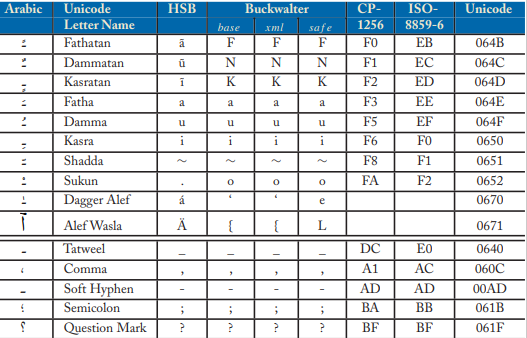

In [6]:
arabic_diacritics = re.compile(r"[\u0617-\u061A\u064B-\u0652]")
arabic_tatweel = "\u0640"

def normalize_arabic(text: str) -> str:
    text = re.sub(arabic_diacritics, "", text)
    text = text.replace("أ", "ا").replace("إ", "ا").replace("آ", "ا")
    text = text.replace("ى", "ي").replace("ة", "ه")
    text = text.replace(arabic_tatweel, "")
    return text

arabic_example = "ٱلسَّلَامُ عَلَيْكُم"
print("Before:", arabic_example)
print("After :", normalize_arabic(arabic_example))

Before: ٱلسَّلَامُ عَلَيْكُم
After : ٱلسلام عليكم


## 4) Tokenization

Tokenization means splitting text into smaller pieces:
- **sentence tokens**
- **word tokens**

A simple `.split()` is not enough for many NLP tasks, because punctuation and contractions can create problems.



In [7]:
text = "Mr. Jack O'Neil works at 245 Yonge Avenue, Austin."

print("Simple split:")
print(text.split())

print("\nRegex-style word tokens:")
print(re.findall(r"\b\w+\b", text))

# NLTK tokenization (requires punkt)
# print("\nNLTK sentence tokens:")
# print(sent_tokenize(text))
# print("\nNLTK word tokens:")
# print(word_tokenize(text))

Simple split:
['Mr.', 'Jack', "O'Neil", 'works', 'at', '245', 'Yonge', 'Avenue,', 'Austin.']

Regex-style word tokens:
['Mr', 'Jack', 'O', 'Neil', 'works', 'at', '245', 'Yonge', 'Avenue', 'Austin']


## 5) Stop words

Stop words are very common words like `the`, `a`, `an`, `is`, `of`, `in`.

They are not always useless. Sometimes they matter.
The important lesson is this: **remove them only when they do not help your task**.

For text classification, removing stop words often helps. For other tasks, you may want to keep them.

In [8]:
# A small manual stopword set so the idea is easy to see.
# In practice, you can use nltk.corpus.stopwords.
simple_stopwords = {"the", "a", "an", "is", "of", "in", "and", "to", "for", "on"}

def remove_stopwords(text: str) -> str:
    tokens = re.findall(r"\b\w+\b", text.lower())
    kept = [t for t in tokens if t not in simple_stopwords]
    return " ".join(kept)

example = "The cat is on the mat and the dog is in the yard."
print(remove_stopwords(example))

cat mat dog yard


## 6) Stemming and lemmatization

These two ideas are easy to confuse:

- **Stemming** chops a word down to a rough root.
- **Lemmatization** tries to return the dictionary form.

stemming is faster and simpler, while lemmatization is more linguistically aware.

In [11]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

words = ["running", "cars", "better", "studies", "communication"]

rows = []
for w in words:
    rows.append({
        "word": w,
        "stem": stemmer.stem(w),
        "lemma": lemmatizer.lemmatize(w),
    })

df = pd.DataFrame(rows)
df

,word,stem,lemma
0,running,run,running
1,cars,car,car
2,better,better,better
3,studies,studi,study
4,communication,commun,communication


In [12]:
# A quick function that shows a full preprocessing chain
def preprocess_pipeline(text: str) -> list[str]:
    text = clean_text(text)
    text = remove_stopwords(text)
    tokens = re.findall(r"\b\w+\b", text)
    return tokens

print(preprocess_pipeline("NLP is really fun, and NLP helps computers read text!"))

['nlp', 'really', 'fun', 'nlp', 'helps', 'computers', 'read', 'text']


## 8) Vectorization: turning text into numbers

Machine learning models cannot work directly on raw text.
They need numbers.

Two classic methods are:
- **Bag of Words (BoW)**
- **TF-IDF**

BoW counts words.
TF-IDF counts words but also reduces the weight of very common ones.

In [13]:
corpus = [
    "nlp is fun",
    "nlp helps computers understand text",
    "text processing is a core part of nlp"
]

count_vec = CountVectorizer()
count_matrix = count_vec.fit_transform(corpus)

count_df = pd.DataFrame(
    count_matrix.toarray(),
    columns=count_vec.get_feature_names_out()
)
count_df

,computers,core,fun,helps,is,nlp,of,part,processing,text,understand
0,0,0,1,0,1,1,0,0,0,0,0
1,1,0,0,1,0,1,0,0,0,1,1
2,0,1,0,0,1,1,1,1,1,1,0


In [14]:
tfidf_vec = TfidfVectorizer()
tfidf_matrix = tfidf_vec.fit_transform(corpus)

tfidf_df = pd.DataFrame(
    np.round(tfidf_matrix.toarray(), 3),
    columns=tfidf_vec.get_feature_names_out()
)
tfidf_df

,computers,core,fun,helps,is,nlp,of,part,processing,text,understand
0,0.000,0.000,0.72,0.000,0.548,0.425,0.000,0.000,0.000,0.000,0.000
1,0.505,0.000,0.00,0.505,0.000,0.298,0.000,0.000,0.000,0.384,0.505
2,0.000,0.426,0.00,0.000,0.324,0.252,0.426,0.426,0.426,0.324,0.000


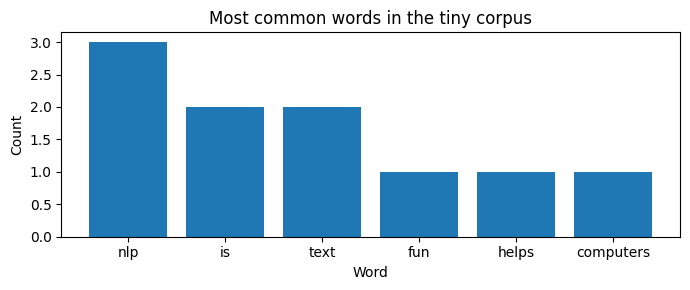

In [16]:
tokens = " ".join(corpus).split()
freq = Counter(tokens).most_common(6)

words = [w for w, _ in freq]
counts = [c for _, c in freq]

plt.figure(figsize=(7, 3))
plt.bar(words, counts)
plt.title("Most common words in the tiny corpus")
plt.xlabel("Word")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 9) A tiny text classification example

This is the simplest useful model pattern for beginners:

1. vectorize text with TF-IDF
2. train a classifier
3. test on a new sentence

**This example is to show the pipeline, dont mind the model accuracy :)**

In [17]:
texts = [
    "The match was exciting and the team scored twice",
    "The player won the tournament after a strong season",
    "The coach praised the defense after the game",
    "The company released a new software update",
    "A startup launched an AI product for businesses",
    "The developer fixed a bug in the app",
]

labels = ["sports", "sports", "sports", "tech", "tech", "tech"]

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.33, random_state=42, stratify=labels
)

model = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

new_text = ["The team launched a new app after the game"]
print("Prediction for new text:", model.predict(new_text)[0])

Accuracy: 0.5
              precision    recall  f1-score   support

      sports       0.50      1.00      0.67         1
        tech       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

Prediction for new text: sports


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 10) Word embeddings

BoW and TF-IDF are sparse vector methods.
Word embeddings are different: they are **dense vectors** where similar words sit closer together.

This idea is one of the big jumps in NLP because it captures more meaning than simple counts.

cat dog 1.0
cat car 0.217
car bus 0.999


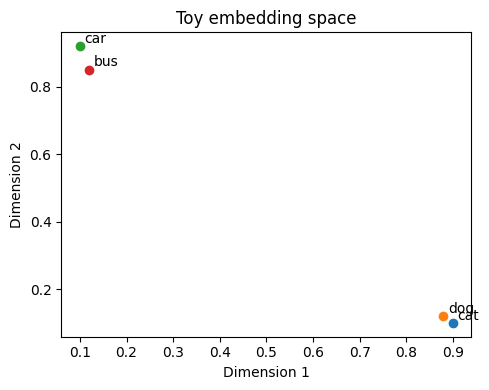

In [18]:
# A tiny toy embedding space
toy_embeddings = {
    "cat": np.array([0.90, 0.10]),
    "dog": np.array([0.88, 0.12]),
    "car": np.array([0.10, 0.92]),
    "bus": np.array([0.12, 0.85]),
}

def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

pairs = [("cat", "dog"), ("cat", "car"), ("car", "bus")]
for a, b in pairs:
    print(a, b, round(cosine_sim(toy_embeddings[a], toy_embeddings[b]), 3))

plt.figure(figsize=(5, 4))
for word, vec in toy_embeddings.items():
    plt.scatter(vec[0], vec[1])
    plt.text(vec[0] + 0.01, vec[1] + 0.01, word)
plt.title("Toy embedding space")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.tight_layout()
plt.show()

### CBOW and Skip-gram

The notes also show the two famous Word2Vec training styles:

- **CBOW** predicts the center word from surrounding context words.
- **Skip-gram** predicts surrounding context words from the center word.

This diagram is a good reminder that Word2Vec is trained from context, not from a dictionary.

<p align="center">
  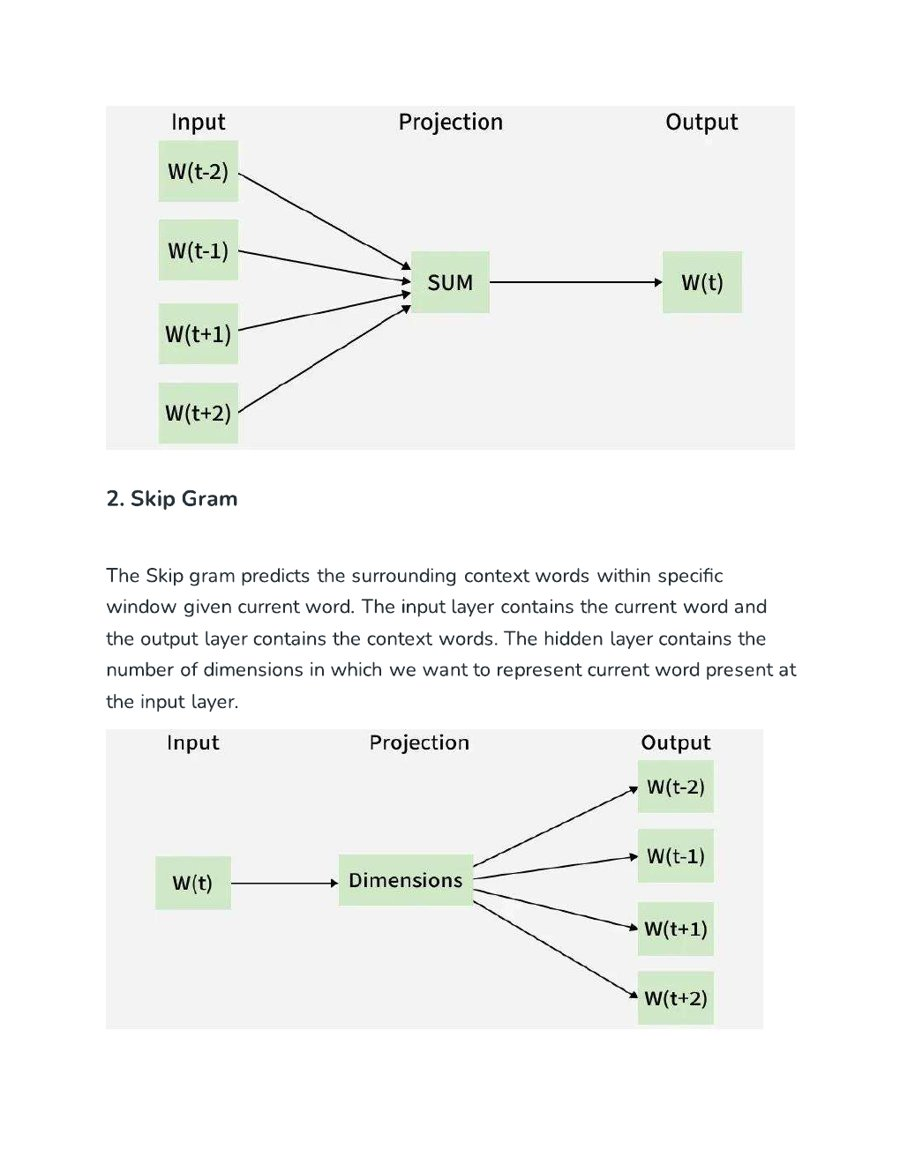
</p>

*The two classic Word2Vec training setups from the notes.*

## 11) Quick recap

If you only remember one pipeline, make it this:

**raw text -> normalize -> clean -> tokenize -> remove noise -> vectorize -> model**

### NLP text processing checklist
- Keep cleaning simple at first.
- Do not remove a feature just because it looks noisy.
- Test on a few examples before scaling up.
- Use TF-IDF before jumping to more complex models.
- Treat stemming and lemmatization as tools, not magic.

### Practice ideas
1. Add URL removal to `clean_text`.
2. Compare BoW and TF-IDF on your own sentences.
3. Replace the tiny classifier corpus with your own text categories.
4. Try the same pipeline on Arabic text and compare the normalization step.